In [1]:
!git clone https://github.com/sakanaowo/DragonFruit

Cloning into 'DragonFruit'...
remote: Enumerating objects: 4730, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 4730 (delta 33), reused 43 (delta 23), pack-reused 4667 (from 2)
Receiving objects: 100% (4730/4730), 1.57 GiB | 40.62 MiB/s, done.
Resolving deltas: 100% (678/678), done.
Updating files: 100% (8908/8908), done.


In [2]:
%cd DragonFruit

/kaggle/working/DragonFruit


In [3]:
!git checkout dev

Updating files: 100% (4466/4466), done.
Branch 'dev' set up to track remote branch 'dev' from 'origin'.
Switched to a new branch 'dev'


In [14]:
!git pull

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 888 bytes | 888.00 KiB/s, done.
From https://github.com/sakanaowo/DragonFruit
   c18773b..ac27821  dev        -> origin/dev
Updating c18773b..ac27821
Fast-forward
 src/evaluate.py | 37 ++++++++++++++++++++++++++-----------
 1 file changed, 26 insertions(+), 11 deletions(-)


In [35]:
import sys
sys.path.append('/kaggle/working/DragonFruit')

In [4]:
!ls

config.yaml  models  outputs	requirements.txt  temp.py
data	     notes   README.md	src		  utils


In [7]:
!cat src/evaluate.py

import os

import torch
from sklearn.metrics import classification_report, accuracy_score
from tqdm import tqdm
# uncomment to run on colab
import sys

sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), '..')))

# //
from src.dataset import get_dataloaders
from utils.config import load_config
from src.model import load_model


def evaluate(model, dataloader, device, class_name):
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Evaluating'):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=class_name)

    print(f"Accuracy: {acc * 100:.2f}%")
    print("Classification R

In [11]:
!cat src/evaluate.py

import os

import torch
from sklearn.metrics import classification_report, accuracy_score
from tqdm import tqdm
# uncomment to run on colab
import sys

sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), '..')))

# //
from src.dataset import get_dataloaders
from utils.config import load_config
from src.model import load_model


def evaluate(model, dataloader, device, class_name):
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Evaluating'):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=class_name)

    print(f"Accuracy: {acc * 100:.2f}%")
    print("Classification R

In [9]:
!python src/evaluate.py

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/kaggle/working/DragonFruit/src/model.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the

Nhận xét:
- "Fungal Infections" và "Healthy Leaves" được phân loại rất tốt (F1 > 0.84).

- "Healthy Fruits" có hiệu suất rất kém, có thể do:

    - Lượng mẫu quá ít (chỉ 17) → mất cân bằng lớp.

    - Đặc trưng hình ảnh không rõ ràng (khó phân biệt healthy vs bệnh).

- "Insect-Infected Fruits" & "Sunburn Damage" có độ chính xác trung bình → có thể bị nhầm lẫn với các lớp tương tự.

Đề xuất:
1. Giải quyết mất cân bằng lớp:
Dùng Weighted Loss (CrossEntropyLoss(weight=class_weights)).

Tăng số lượng ảnh cho các lớp hiếm qua data augmentation.

Hoặc dùng oversampling/WeightedRandomSampler.

2. Cải thiện kiến trúc mô hình:
Dùng ResNet101 hoặc thử các backbone mạnh hơn (EfficientNet, ConvNeXt...).

Dùng thêm dropout/batchnorm nếu chưa có.

3. Kiểm tra confusion matrix:
Để thấy rõ mô hình đang nhầm lẫn lớp nào với lớp nào:

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/kaggle/working/DragonFruit/src/model.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the


Accuracy: 78.72%
Classification Report:
                                                 precision    recall  f1-score   support

Fungal Infections (Anthracnose or Stem Canker)       0.88      0.80      0.84       342
                                Healthy Fruits       0.38      0.35      0.36        17
                                Healthy Leaves       0.79      0.93      0.86       187
                        Insect-Infected Fruits       0.55      0.76      0.64        34
                                Sunburn Damage       0.64      0.53      0.58        92

                                      accuracy                           0.79       672
                                     macro avg       0.65      0.68      0.66       672
                                  weighted avg       0.79      0.79      0.79       672



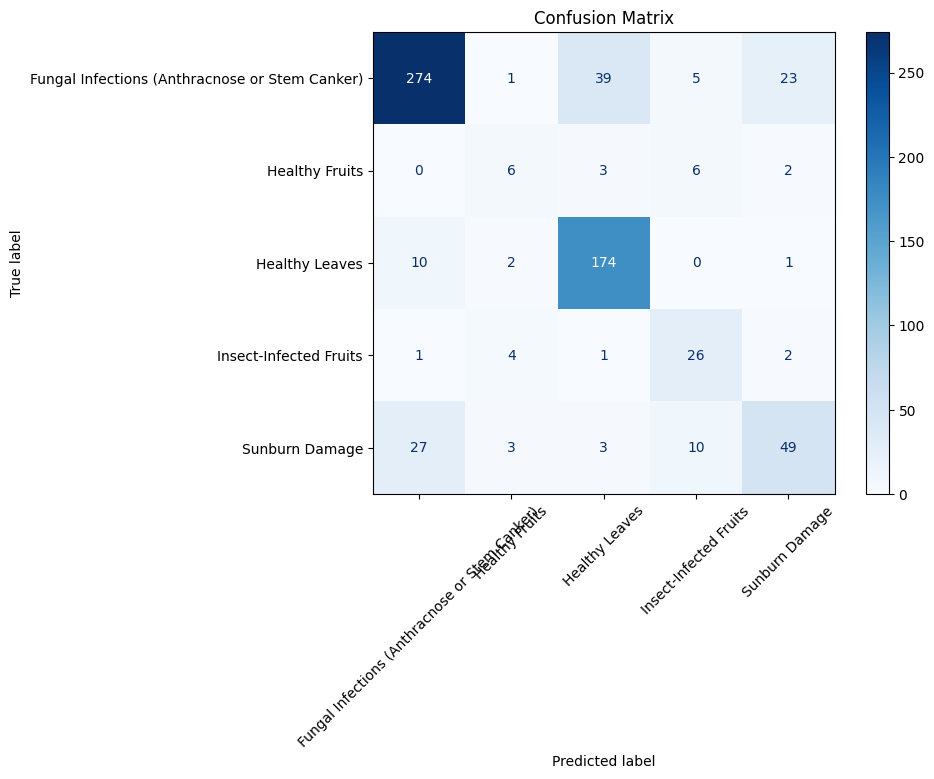

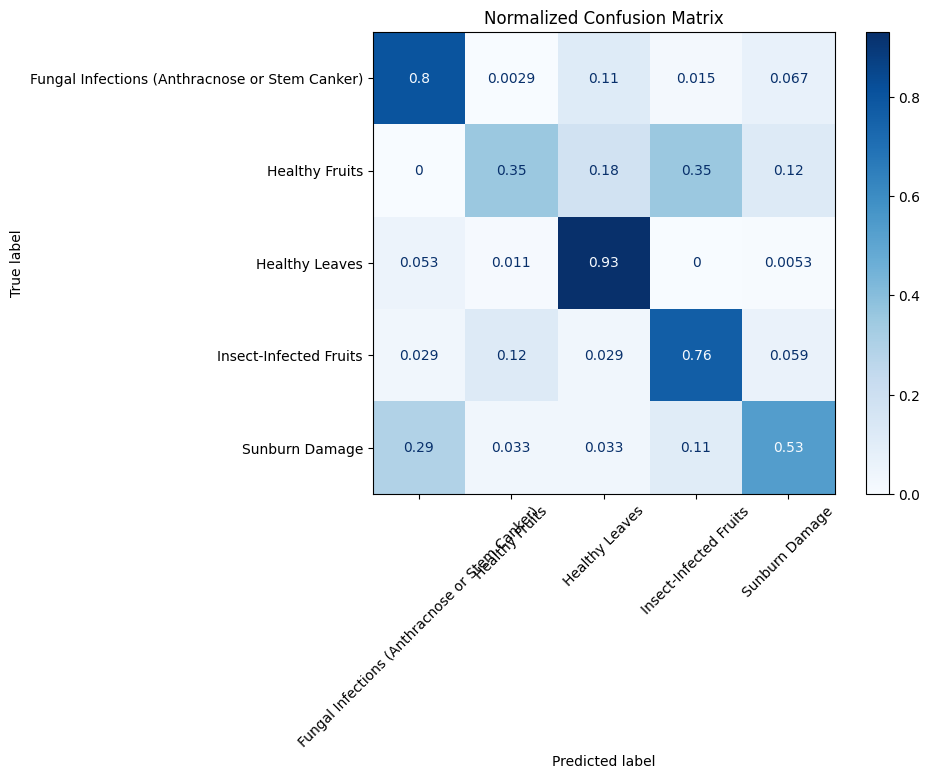

In [13]:
# kiểm tra confusion
import os
import sys
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Thêm đường dẫn để import module
# sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), '..')))

from src.dataset import get_dataloaders
from utils.config import load_config
from src.model import load_model


def evaluate(model, dataloader, device, class_names):
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Evaluating'):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=class_names)

    print(f"\nAccuracy: {acc * 100:.2f}%")
    print("Classification Report:\n", report)

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
    plt.title("Confusion Matrix")
    plt.show()

    # Normalized Confusion Matrix
    cm_norm = confusion_matrix(all_labels, all_preds, normalize='true')
    disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp_norm.plot(ax=ax, cmap='Blues', xticks_rotation=45)
    plt.title("Normalized Confusion Matrix")
    plt.show()

    return acc, report


if __name__ == '__main__':
    config = load_config()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = load_model(device)

    dataloader = get_dataloaders(
        config['data']['train_dir'],
        config['data']['val_dir'],
        config['data']['test_dir'],
        config['data']['batch_size'],
        config['data']['num_workers'],
    )
    class_names = config['data']['class_names']
    evaluate(model, dataloader['test'], device, class_names)


Sunburn Damage:

- Chỉ đúng 53%

- Bị nhầm sang Fungal Infections (29%) và Insect-Infected Fruits (11%)

- Có thể vì tổn thương do nắng gây hiện tượng thị giác giống bệnh lý.

Healthy Fruits:

- Dự đoán đúng: chỉ 35%

- Nhầm nhiều nhất sang:

    - Insect-Infected Fruits: 35%

    - Healthy Leaves: 18%

- Có thể do dữ liệu chưa đủ hoặc quả khỏe mạnh dễ bị nhầm với các loại ít bệnh.